# S5_Sentinel_TUOL_QC.ipynb
This notebook investigates the Sentinel-1 QC algorithm over the Tuolumne (TUOL) site.

For additional details see ../paper_new/fig_4_tuolumne_S1_VV_QC_persistence.ipynb


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
import xarray as xr
from pathlib import Path
import contextily as ctx


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [5]:
sys.path.insert(1, '../scripts/')

In [6]:
import metadata as metadata


In [7]:
import importlib
importlib.reload(metadata)


<module 'metadata' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/metadata.py'>

# Load Data

## Metadata

In [8]:
# tuolumne.
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))


In [9]:
importlib.reload(metadata)
# tuolumne
tuolumne_geog_fpath,aso_crs = metadata.get_shapefile_fpath(tuolumne_cfg,"shapefile_fpath","zoom_1")
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
uscatm_geog_fpath,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCATM")
# read shapefile
## uscatm
uscatm_geog_gdf = gpd.read_file(uscatm_geog_fpath)
uscatm_proj_gdf = uscatm_geog_gdf.to_crs(f'EPSG:{aso_crs}')
## tuolumne
tuolumne_geog_gdf = gpd.read_file(tuolumne_geog_fpath)
tuolumne_proj_gdf = tuolumne_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## Helper functions

In [10]:
def dem_match_bin(aso_data: xr.DataArray,
                  aso_dem: xr.DataArray,
                  bins: np.ndarray,
                  is50mSWE: bool = True,
                  isSnowModel: bool = False,
                  nan_thresh_: int = 1):
    """
    Reproject and match aso dem to aso swe grid. Create dataarray containing different
    dem grids.
    ASSUMPTIONS: three bins (low, mid, high)
    Input:
      aso_data - xarray dataarray for aso swe flights that have been subsetted.
      aso_dem - xarray dataarray for aso dem that have not been subsetted.
      bins - python list float values for left bound of mid and high bins

    Output:
      geom_proj - geopandas object for clipped basin shape.
    """
    aso_dem_match = aso_dem
    aso_dem_match = aso_dem_match * 1
    ## assign bins ##
    bin_vals = list(bins)
    bin_vals.insert(0, float(aso_dem_match.min().values))
    bin_vals.append(float(aso_dem_match.max().values))
    if list(bins) == [5000.0,8000.0]:
      bin_labels = ['low','mid','high']
    else:
      bin_labels = [f'<{int(bins[0])}']
      for i in range(1,len(bins)):
        bin_labels.append(f'{int(bins[i-1])}-{int(bins[i])}')
      bin_labels.append(f'>{int(bins[-1])}')

    data = []
    for i in range(0,len(bin_vals)-1):
        arr = aso_dem_match.where((aso_dem_match >= bin_vals[i]) & (aso_dem_match < bin_vals[i+1])).values.reshape(1,aso_dem_match.shape[0],aso_dem_match.shape[1])
        da = xr.DataArray(
          data=arr,
          dims=["elev","y", "x"],
          coords=dict(
              elev=(["elev"], [bin_labels[i]]),
              y=(["y"], aso_dem_match["y"].values),
              x=(["x"], aso_dem_match["x"].values)
              )
         )
        data.append(da)

    arr = aso_dem_match.values.reshape(1,aso_dem_match.shape[0],aso_dem_match.shape[1])
    da = xr.DataArray(
         data=arr,
         dims=["elev","y", "x"],
         coords=dict(
             elev=(["elev"], ['total']),
             y=(["y"], aso_dem_match["y"].values),
             x=(["x"], aso_dem_match["x"].values)
            )
         )
    data.append(da)
    return xr.concat(data, dim="elev")


In [11]:
import pyproj
def sm_geog_curvilinear_to_rectilinear(ds,
                                       var = 'VEG',
                                       proj_string = '+proj=lcc +lat_1=30.0 +lat_2=50.0 +lat_0=39.100006 +lon_0=-97.9 +a=6370000 +b=6370000 +type=crs'):
    p = pyproj.Proj(proj_string)
    proj_x,proj_y = p(ds.XLONG.values,ds.XLAT.values,inverse = False)

    ## convert 2D lat/lon to 1D for rio reprojection and clipping ##
    lon_2v = proj_x[int(ds.XLAT.shape[0]/2),:]
    lat_2v = proj_y[:,int(ds.XLAT.shape[1]/2)]

    da = xr.DataArray(
    data = ds[var].values,
    dims = ["y","x"],
    coords = dict(
        y = (["y"], lat_2v),
        x = (["x"], lon_2v),
    )
    )
    da.name = var
    da = da.rio.write_crs(proj_string, inplace=False)
    return da

def veg_to_bins(da):
    ds = da.to_dataset()
    ## vegetation mapping ##
    ds['VEG'] = ds.VEG.astype(int)
    conditions  = [ (ds.VEG == 1) | (ds.VEG == 2) | (ds.VEG == 3) | (ds.VEG == 4) | (ds.VEG == 5), # forest
               (ds.VEG == 6) | (ds.VEG == 7) | (ds.VEG == 8) | (ds.VEG == 9) | (ds.VEG == 10) | (ds.VEG == 11), # shrub
               (ds.VEG == 12) | (ds.VEG == 13) | (ds.VEG == 14) | (ds.VEG == 15) | (ds.VEG == 16) | (ds.VEG == 17), # grass
               (ds.VEG == 18),  # bare
               (ds.VEG == 19) | (ds.VEG == 20) | (ds.VEG == 24), # water
               (ds.VEG == 21) | (ds.VEG == 22) | (ds.VEG == 23), # human
              ]
              
    choices     = [1, # forest
               2, # shrub
               3, # grass
               4, # bare
               5, # water
               6 # human
              ]
    dir_array = np.select(conditions, choices, default=np.nan)
    ds['veg_bin'] = xr.DataArray(data = dir_array,dims = ["y","x"])
    ds['veg_bin'] = ds.veg_bin.astype(int)
    return ds,choices
    

In [12]:
def add_terrain_bins_for_tuolumne_no_lia(
    terrain_ds: xr.Dataset,
    *,
    elev_bin_m=100.0,          # 100-meter elevation bins
    hgt_var="hgt",
    elev_dim="elev",
    use_total_if_present=True,
    load_to_memory=True,
) -> xr.Dataset:
    """
    Adds (NO LIA):
      - elev_bin(y,x) int16 (100-m bins)
      - elev_bin_edges

    Does NOT add lia_bin / lia_bin_edges.
    """
    ds = terrain_ds.load() if load_to_memory else terrain_ds

    # -------------------------
    # Height (y,x) from hgt
    # (your hgt sometimes stored as (elev,y,x); we want a 2D DEM)
    # -------------------------
    hgt = ds[hgt_var]
    if elev_dim in hgt.dims:
        if use_total_if_present and (elev_dim in ds.coords) and ("total" in ds.coords[elev_dim].values):
            hgt2d = hgt.sel({elev_dim: "total"})
        else:
            hgt2d = hgt.median(elev_dim, skipna=True)
    else:
        hgt2d = hgt

    # -------------------------
    # Elevation bins: 100 m
    # -------------------------
    dz = float(elev_bin_m)
    h = hgt2d.values
    hmin = np.nanmin(h)
    hmax = np.nanmax(h)
    elev_edges = np.arange(np.floor(hmin / dz) * dz, np.ceil(hmax / dz) * dz + dz, dz)

    elev_bin = (np.digitize(h, elev_edges) - 1).astype(np.int16)

    ds = ds.assign(
        elev_bin=xr.DataArray(elev_bin, dims=("y", "x"), coords={"y": ds["y"], "x": ds["x"]}),
        elev_bin_edges=xr.DataArray(elev_edges, dims=("elev_bin_edge",)),
    )

    return ds


## Terrain loading

In [13]:
sm_tuolumne_biased_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "biased")


In [14]:
sm_tuol_ctrl_ds = xr.load_dataset(f'{sm_tuolumne_biased_fpath}wy_2017/geography/ctrl_geog.nc')
# snowmodel elevation/vegetation
veg_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'VEG',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')
hgt_proj_da = sm_geog_curvilinear_to_rectilinear(sm_tuol_ctrl_ds,var = 'HGT',proj_string = '+proj=utm +zone=11 +datum=WGS84 +units=m +no_defs +type=crs')

elev_arr = np.arange(2750,
                     3750,
                     200)
dem_frac = dem_match_bin(hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry),
                  hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry),
                  elev_arr,
                  is50mSWE = True,
                  isSnowModel = False,
                  nan_thresh_ = 1)

veg_proj_ds,_ = veg_to_bins(veg_proj_da)


In [15]:
terrain_ds = dem_frac[-1].to_dataset(name = 'hgt')
terrain_ds['landcover'] = veg_proj_ds["veg_bin"].rio.clip(tuolumne_proj_gdf.geometry)
terrain_mem = terrain_ds.load()


In [16]:
terrain_binned = add_terrain_bins_for_tuolumne_no_lia(
    terrain_mem,
    elev_bin_m=400,
)


## ASO

In [17]:
# all aso flights.
aso_ds = xr.load_dataset('~/rmower/aso/data/aso/USCATM/processed/ASO_50M_SWE_SPATIAL.nc')
# all aso peak SWE flights.
peak_swe = np.array(['2017-05-02','2018-04-23','2019-04-17','2020-04-13'],dtype = np.datetime64)
aso_slice = aso_ds.where(aso_ds.date.isin(peak_swe),drop = True)
aso_slice.rio.write_crs(aso_crs,inplace=True)
# clip to distributed domain.
aso_slice = aso_slice.rio.clip(tuolumne_proj_gdf.geometry)
# aso dem.
aso_dem_ds = xr.load_dataset('~/rmower/aso/data/dem/USCATM/processed/ASO_50M_PCDTM_USCATM_bins_1000ft.nc')
aso_dem_da = aso_dem_ds.dem_bin[-1]
aso_dem_da.rio.write_crs(aso_crs,inplace=True)


<xarray.DataArray 'dem_bin' (y: 1004, x: 1045)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    elev         <U11 44B 'total'
  * y            (y) float64 8kB 4.23e+06 4.23e+06 ... 4.179e+06 4.179e+06
  * x            (x) float64 8kB 2.543e+05 2.544e+05 ... 3.065e+05 3.065e+05
    spatial_ref  int64 8B 0

## S1-VV data (2017–2020)

In [18]:

tu_vv_2017 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2017_wetness_phase.nc")
tu_vv_2018 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2018_wetness_phase.nc")
tu_vv_2019 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2019_wetness_phase.nc")
tu_vv_2020 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2020_wetness_phase.nc")

### Year-count computation

In [19]:
# Stack qc_ok as float so NaN pixels (outside basin) remain NaN
qc_stack = np.stack([ds['qc_ok'].values.astype(float)
                     for ds in [tu_vv_2017, tu_vv_2018, tu_vv_2019, tu_vv_2020]], axis=0)

# 0 = never passed QC, 4 = always passed QC
year_count = np.nansum(qc_stack, axis=0).astype(float)
year_count[np.all(np.isnan(qc_stack), axis=0)] = np.nan

unique, counts = np.unique(year_count[~np.isnan(year_count)].astype(int), return_counts=True)
print("Year count distribution:")
for u, c in zip(unique, counts):
    print(f"  {u} years: {c:,} pixels ({100*c/counts.sum():.1f}%)")

Year count distribution:
  0 years: 23,859 pixels (45.5%)
  1 years: 10,024 pixels (19.1%)
  2 years: 9,050 pixels (17.3%)
  3 years: 6,831 pixels (13.0%)
  4 years: 2,616 pixels (5.0%)


# S1-VV QC Figure

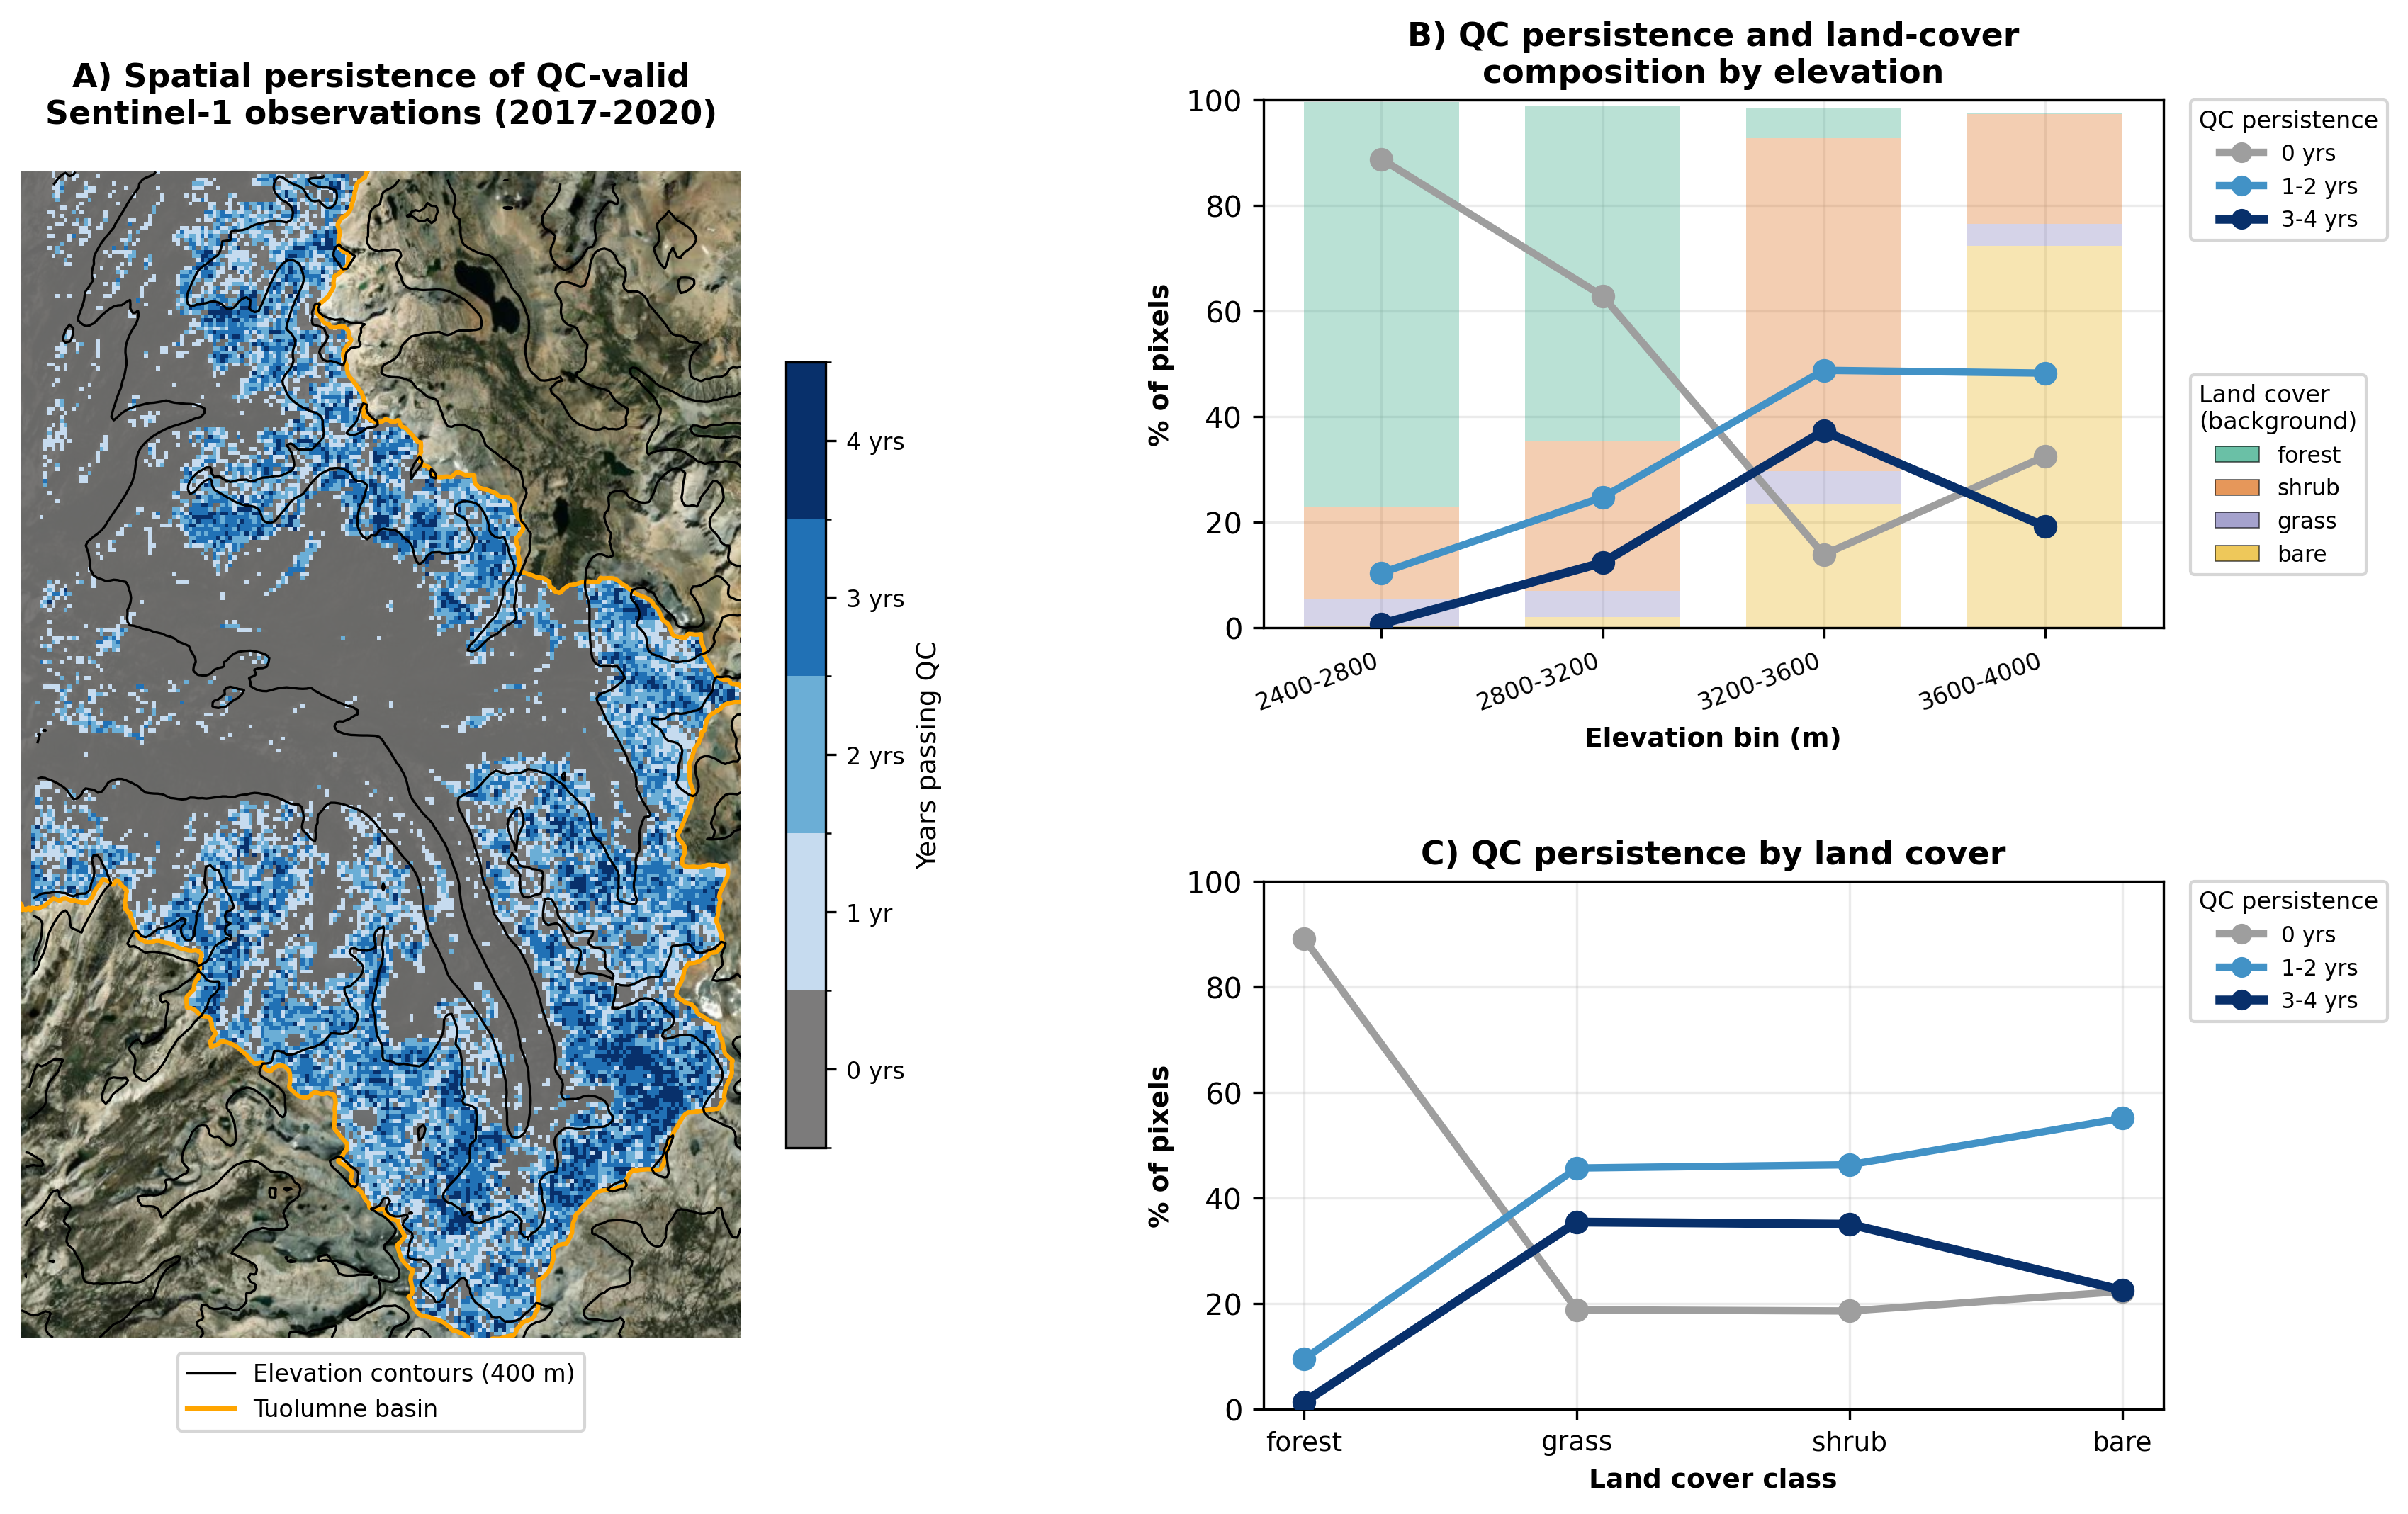

In [20]:
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.enums import Resampling

# ── Recompute shared arrays ────────────────────────────────────────────────────
elev_bin_da = terrain_binned["elev_bin"].rio.write_crs(f"EPSG:{aso_crs}")
year_count_da = xr.DataArray(
    year_count, dims=["y", "x"],
    coords={"y": tu_vv_2017.y.values, "x": tu_vv_2017.x.values}
).rio.write_crs(f"EPSG:{aso_crs}")

hgt_uscatm  = terrain_binned["hgt"].rio.write_crs(f"EPSG:{aso_crs}").rio.clip(
    uscatm_proj_gdf.geometry, drop=False)
uscatm_mask = np.isfinite(hgt_uscatm.values)

year_count_uscatm = year_count_da.rio.clip(
    uscatm_proj_gdf.geometry, drop=False).values
year_count_m = (
    year_count_da.rio.clip(uscatm_proj_gdf.geometry, drop=False)
    .rio.reproject_match(elev_bin_da, resampling=Resampling.nearest)
    .values
)
year_count_m[~uscatm_mask] = np.nan

elev_bin_vals = elev_bin_da.values
lc_vals       = terrain_binned["landcover"].values
target_bins   = [1, 2, 3, 4]
bin_labels    = ["2400-2800", "2800-3200", "3200-3600", "3600-4000"]

# ── QC persistence groups (3 categories, per-category linewidth) ───────────────
# (label, lo, hi, color, linewidth)
PERSIST = [
    ("0 yrs",   0, 0, "#9e9e9e", 2.5),  # never valid  — neutral gray
    ("1-2 yrs", 1, 2, "#4292c6", 2.5),  # intermittent — medium blue
    ("3-4 yrs", 3, 4, "#08306b", 3.0),  # persistent   — dark navy, thicker
]

# ── Land cover background — high-contrast palette under transparency ───────────
# Stack order: bare (bottom) → grass → shrub → forest (top)
# Colors chosen to remain visually distinct at alpha=0.30
LC_BG = [
    ("bare",   4, "#e6ab02"),  # tan
    ("grass",  3, "#7570b3"),  # light green
    ("shrub",  2, "#d95f02"),  # olive
    ("forest", 1, "#1b9e77"),  # dark green
]
ALPHA_BG = 0.30

# ── QC persistence colormap (Panel A) ─────────────────────────────────────────
COUNT_COLORS = {0: "#706f6fea", 1: "#c6dbef", 2: "#6baed6", 3: "#2171b5", 4: "#08306b"}
COUNT_LABELS = {0: "0 yrs", 1: "1 yr", 2: "2 yrs", 3: "3 yrs", 4: "4 yrs"}
cmap_count   = mcolors.ListedColormap([COUNT_COLORS[i] for i in range(5)])
bnorm        = mcolors.BoundaryNorm(np.arange(-0.5, 5, 1), cmap_count.N)

TITLE_FS = 11
LBL_FS   = 9
LW_BASIN = 1.5
LEG_FS   = 7.5    # legend font size
LEG_TFS  = 8.0    # legend title font size
LEG_X    = 1.03   # bbox_to_anchor x for outside-axes legends

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(dpi=300, figsize=(13, 8))   # extra width for right-margin legends
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.38, hspace=0.48)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A — QC persistence spatial map (USCATM basin)
# ══════════════════════════════════════════════════════════════════════════════
xx_vv, yy_vv = np.meshgrid(tu_vv_2017.x.values, tu_vv_2017.y.values)
ax1.set_xlim(xx_vv.min(), xx_vv.max())
ax1.set_ylim(yy_vv.min(), yy_vv.max())

ctx.add_basemap(ax=ax1, crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
pcm = ax1.pcolormesh(xx_vv, yy_vv, year_count_uscatm, cmap=cmap_count, norm=bnorm,
                     rasterized=True, zorder=2)
uscatm_proj_gdf.plot(ax=ax1, color="none", edgecolor="orange", linewidth=LW_BASIN, zorder=5)
hgt_clip = hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry)
ax1.contour(hgt_clip.x.values, hgt_clip.y.values, hgt_clip.values,
            levels=[2400, 2800, 3200, 3600, 4000],
            colors="black", linewidths=0.8, zorder=6)
ax1.set_title(
    "a) Spatial persistence of QC-valid\nSentinel-1 observations (2017-2020)",
    fontweight="bold", fontsize=TITLE_FS)
ax1.axis("off")
ax1.set_aspect("equal")
cbar = fig.colorbar(pcm, ax=ax1, ticks=range(5), shrink=0.6)
cbar.ax.set_yticklabels([COUNT_LABELS[i] for i in range(5)], fontsize=8)
cbar.set_label("Years passing QC", fontsize=9)

# ── Shared map legend (below Panel A) ─────────────────────────────────────────
map_handles = [
    Line2D([0],[0], color="black", linewidth=0.8, label="Elevation contours (400 m)"),
    Line2D([0],[0], color="orange", linewidth=LW_BASIN, label="Tuolumne basin"),
]
ax1.legend(handles=map_handles, fontsize=8, frameon=True,
           loc="lower center", bbox_to_anchor=(0.5, -0.09), ncol=1)

# ══════════════════════════════════════════════════════════════════════════════
# Panel B — QC persistence vs elevation + land-cover composition (background)
# ══════════════════════════════════════════════════════════════════════════════
ax2.set_axisbelow(True)

# Background: stacked bars — LC fraction per elevation bin
bottoms = np.zeros(len(target_bins))
for lc_name, lc_code, lc_color in LC_BG:
    heights = np.array([
        100 * np.sum((lc_vals == lc_code) & (elev_bin_vals == b) & uscatm_mask)
        / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.bar(range(len(bin_labels)), heights, bottom=bottoms,
            color=lc_color, alpha=ALPHA_BG, width=0.7, zorder=1, edgecolor="none")
    bottoms += heights

# Foreground: QC persistence lines
for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] >= lo) &
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] <= hi)
        ) / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.plot(range(len(bin_labels)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, zorder=3)

ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=20, ha="right", fontsize=8)
ax2.set_xlabel("Elevation bin (m)", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.25)
ax2.set_title("b) QC persistence and land-cover\ncomposition by elevation",
              fontweight="bold", fontsize=TITLE_FS)

# Legends outside axes — stacked vertically on the right margin
qc_handles = [
    Line2D([0],[0], color=c, linewidth=lw, marker="o", markersize=6, label=lbl)
    for lbl, lo, hi, c, lw in PERSIST
]
lc_bg_handles = [
    Patch(facecolor=c, alpha=0.65, edgecolor="k", linewidth=0.4, label=n)
    for n, _, c in reversed(LC_BG)  # forest at top of legend = top of stack
]

leg_b1 = ax2.legend(handles=qc_handles, title="QC persistence",
                    fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
                    loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
                    borderaxespad=0)
ax2.add_artist(leg_b1)
ax2.legend(handles=lc_bg_handles, title="Land cover\n(background)",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 0.48),
           borderaxespad=0)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C — QC persistence by land cover (forest → grass → shrub → bare)
# ══════════════════════════════════════════════════════════════════════════════
lc_cats_c = [("forest", 1), ("grass", 3), ("shrub", 2), ("bare", 4)]
lc_lbls_c = [lc[0] for lc in lc_cats_c]

ax3.set_axisbelow(True)

for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(lc_vals == code) & uscatm_mask] >= lo) &
            (year_count_m[(lc_vals == code) & uscatm_mask] <= hi)
        ) / max(np.sum((lc_vals == code) & uscatm_mask), 1)
        for _, code in lc_cats_c
    ])
    ax3.plot(range(len(lc_lbls_c)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, label=label, zorder=3)

ax3.set_xticks(range(len(lc_lbls_c)))
ax3.set_xticklabels(lc_lbls_c, fontsize=9)
ax3.set_xlabel("Land cover class", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.25)
ax3.set_title("c) QC persistence by land cover",
              fontweight="bold", fontsize=TITLE_FS)

# Legend outside axes — right margin, aligned with Panel B
ax3.legend(handles=qc_handles, title="QC persistence",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
           borderaxespad=0)

plt.tight_layout()
# plt.savefig("./pngs/S6_TUOL_S1_VV_QC.png", dpi=300, bbox_inches="tight")
plt.show()


# S1-Rc QC Figure

## load S1-RC data and get QC counts

In [21]:
# NOTE OVERWRITING
tu_vv_2017 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}rc/2017_wetness_phase.nc")
tu_vv_2018 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}rc/2018_wetness_phase.nc")
tu_vv_2019 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}rc/2019_wetness_phase.nc")
tu_vv_2020 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}rc/2020_wetness_phase.nc")

# Stack qc_ok as float so NaN pixels (outside basin) remain NaN
qc_stack = np.stack([ds['qc_ok'].values.astype(float)
                     for ds in [tu_vv_2017, tu_vv_2018, tu_vv_2019, tu_vv_2020]], axis=0)

# 0 = never passed QC, 4 = always passed QC
year_count = np.nansum(qc_stack, axis=0).astype(float)
year_count[np.all(np.isnan(qc_stack), axis=0)] = np.nan

unique, counts = np.unique(year_count[~np.isnan(year_count)].astype(int), return_counts=True)
print("Year count distribution:")
for u, c in zip(unique, counts):
    print(f"  {u} years: {c:,} pixels ({100*c/counts.sum():.1f}%)")

Year count distribution:
  0 years: 30,296 pixels (57.8%)
  1 years: 12,327 pixels (23.5%)
  2 years: 7,538 pixels (14.4%)
  3 years: 2,219 pixels (4.2%)


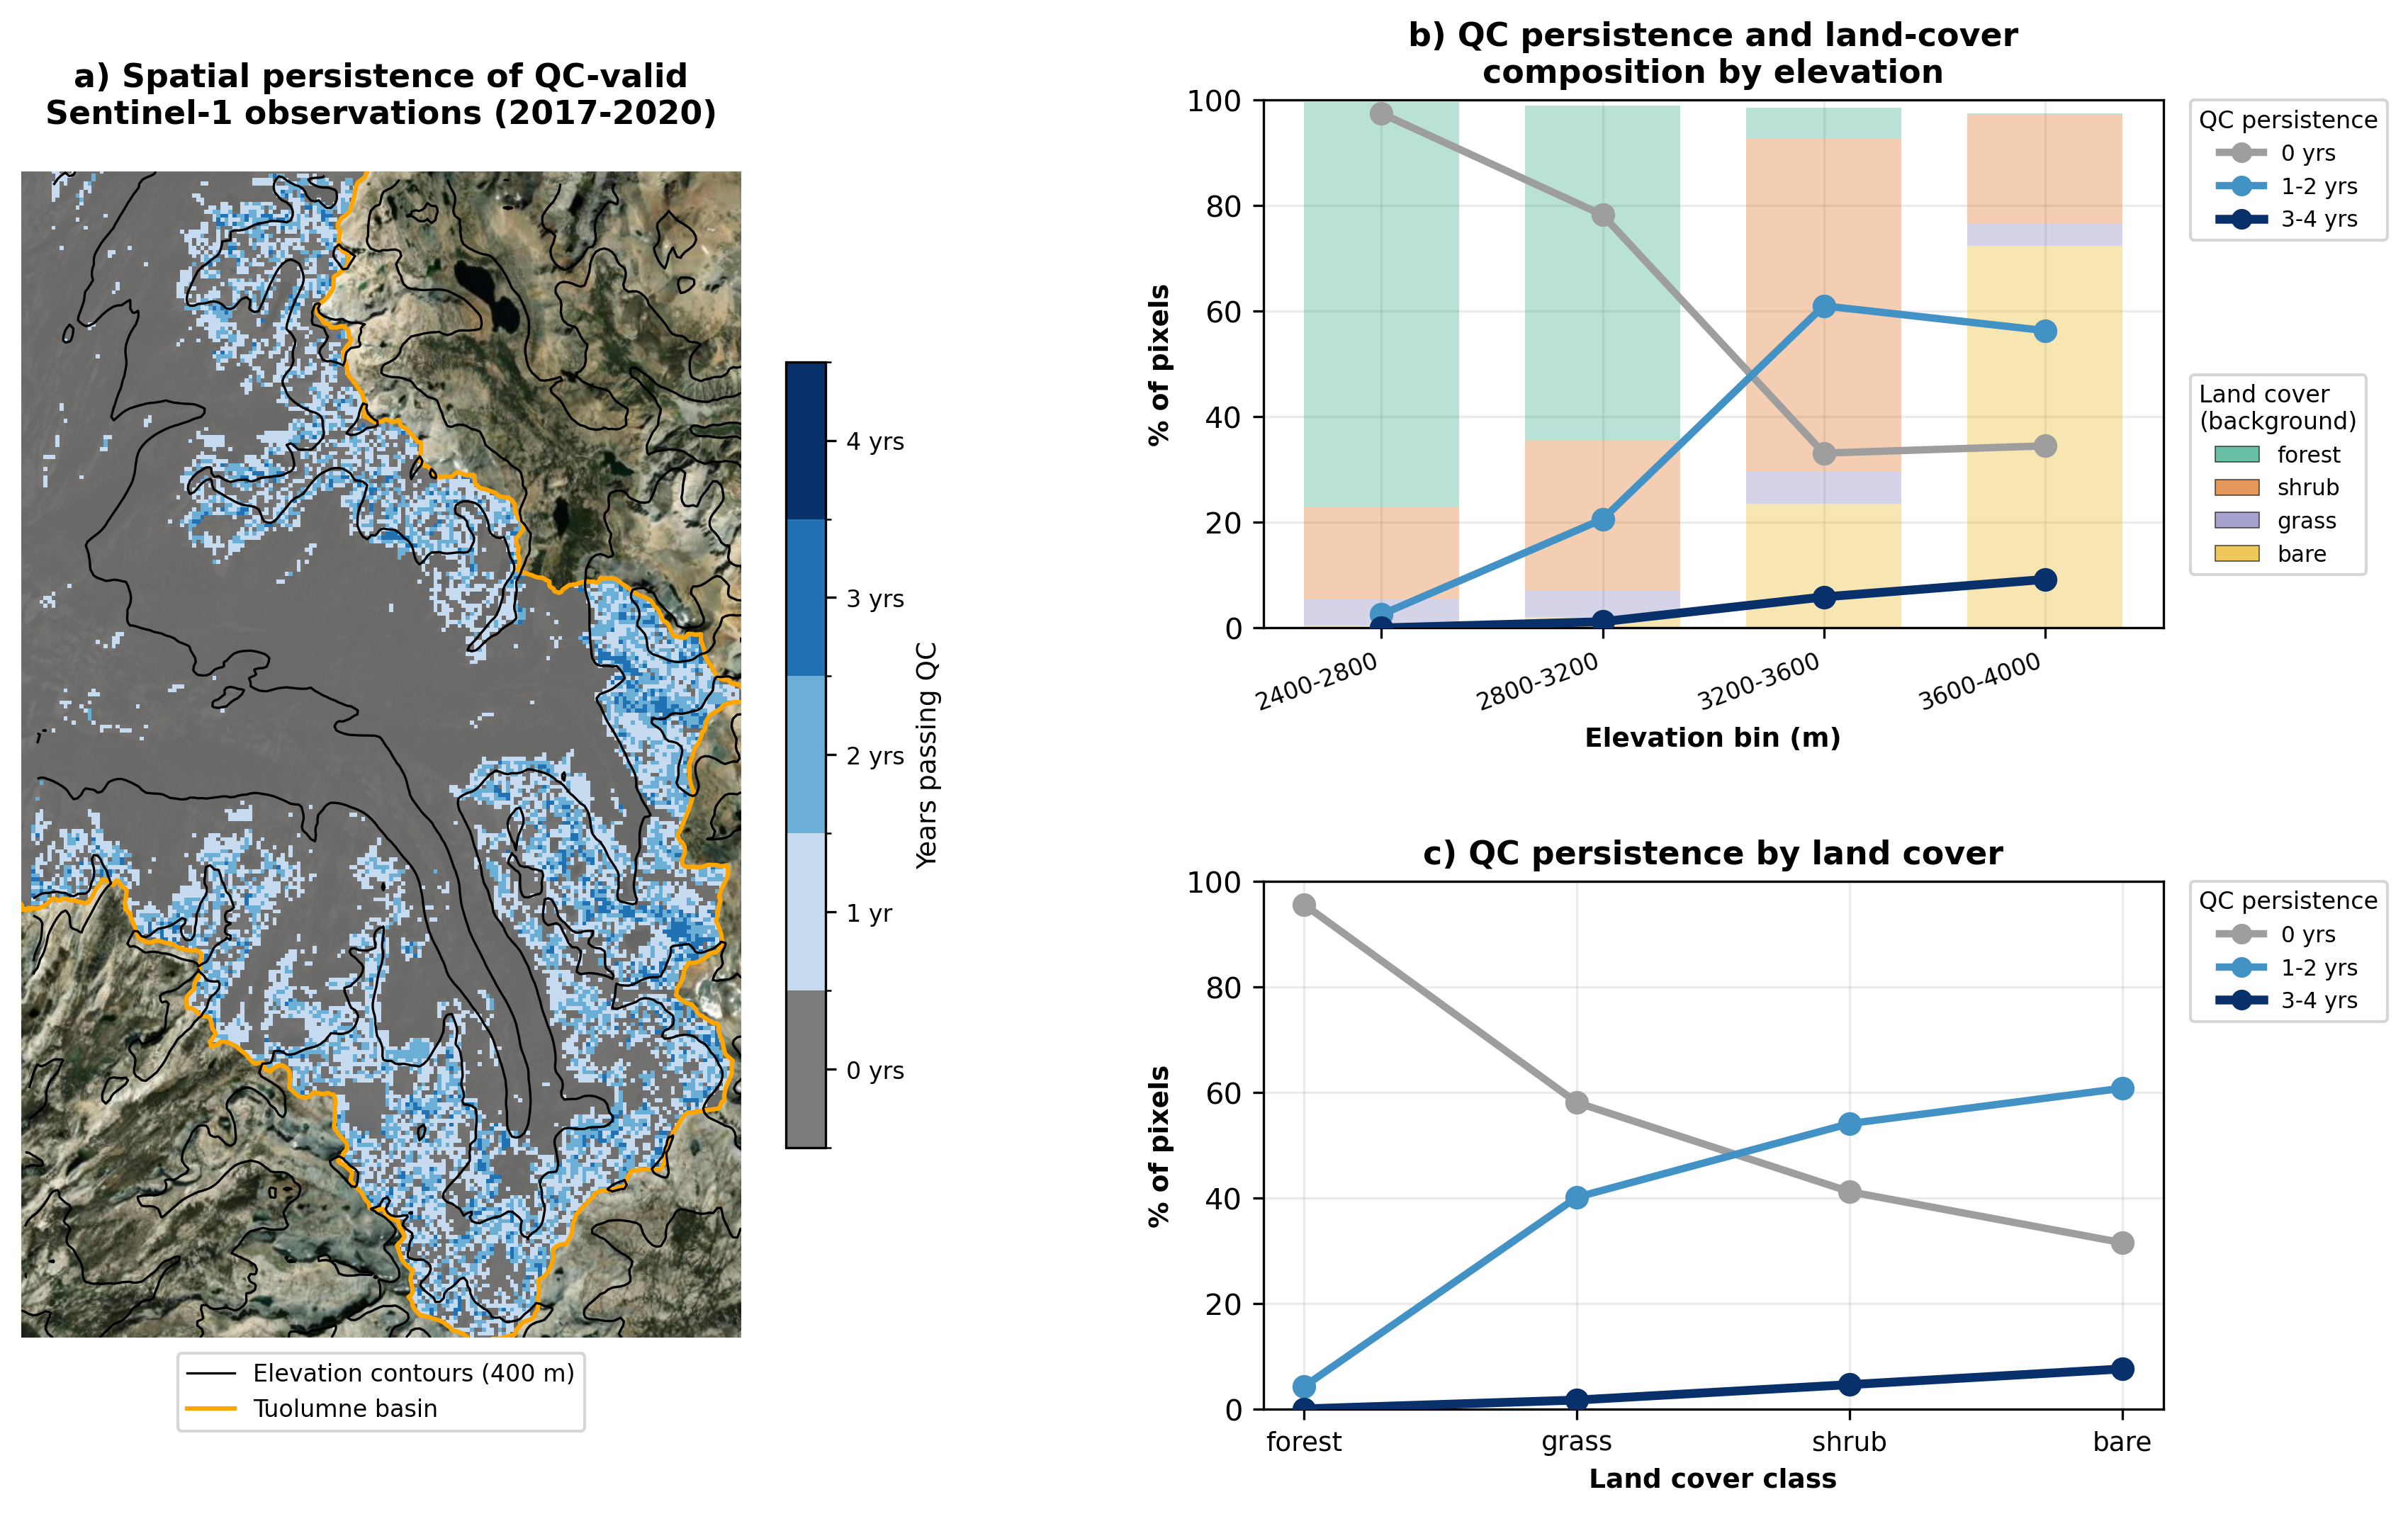

In [23]:
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterio.enums import Resampling

# ── Recompute shared arrays ────────────────────────────────────────────────────
elev_bin_da = terrain_binned["elev_bin"].rio.write_crs(f"EPSG:{aso_crs}")
year_count_da = xr.DataArray(
    year_count, dims=["y", "x"],
    coords={"y": tu_vv_2017.y.values, "x": tu_vv_2017.x.values}
).rio.write_crs(f"EPSG:{aso_crs}")

hgt_uscatm  = terrain_binned["hgt"].rio.write_crs(f"EPSG:{aso_crs}").rio.clip(
    uscatm_proj_gdf.geometry, drop=False)
uscatm_mask = np.isfinite(hgt_uscatm.values)

year_count_uscatm = year_count_da.rio.clip(
    uscatm_proj_gdf.geometry, drop=False).values
year_count_m = (
    year_count_da.rio.clip(uscatm_proj_gdf.geometry, drop=False)
    .rio.reproject_match(elev_bin_da, resampling=Resampling.nearest)
    .values
)
year_count_m[~uscatm_mask] = np.nan

elev_bin_vals = elev_bin_da.values
lc_vals       = terrain_binned["landcover"].values
target_bins   = [1, 2, 3, 4]
bin_labels    = ["2400-2800", "2800-3200", "3200-3600", "3600-4000"]

# ── QC persistence groups (3 categories, per-category linewidth) ───────────────
# (label, lo, hi, color, linewidth)
PERSIST = [
    ("0 yrs",   0, 0, "#9e9e9e", 2.5),  # never valid  — neutral gray
    ("1-2 yrs", 1, 2, "#4292c6", 2.5),  # intermittent — medium blue
    ("3-4 yrs", 3, 4, "#08306b", 3.0),  # persistent   — dark navy, thicker
]

# ── Land cover background — high-contrast palette under transparency ───────────
# Stack order: bare (bottom) → grass → shrub → forest (top)
# Colors chosen to remain visually distinct at alpha=0.30
LC_BG = [
    ("bare",   4, "#e6ab02"),  # tan
    ("grass",  3, "#7570b3"),  # light green
    ("shrub",  2, "#d95f02"),  # olive
    ("forest", 1, "#1b9e77"),  # dark green
]
ALPHA_BG = 0.30

# ── QC persistence colormap (Panel A) ─────────────────────────────────────────
COUNT_COLORS = {0: "#706f6fea", 1: "#c6dbef", 2: "#6baed6", 3: "#2171b5", 4: "#08306b"}
COUNT_LABELS = {0: "0 yrs", 1: "1 yr", 2: "2 yrs", 3: "3 yrs", 4: "4 yrs"}
cmap_count   = mcolors.ListedColormap([COUNT_COLORS[i] for i in range(5)])
bnorm        = mcolors.BoundaryNorm(np.arange(-0.5, 5, 1), cmap_count.N)

TITLE_FS = 11
LBL_FS   = 9
LW_BASIN = 1.5
LEG_FS   = 7.5    # legend font size
LEG_TFS  = 8.0    # legend title font size
LEG_X    = 1.03   # bbox_to_anchor x for outside-axes legends

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(dpi=300, figsize=(13, 8))   # extra width for right-margin legends
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.38, hspace=0.48)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A — QC persistence spatial map (USCATM basin)
# ══════════════════════════════════════════════════════════════════════════════
xx_vv, yy_vv = np.meshgrid(tu_vv_2017.x.values, tu_vv_2017.y.values)
ax1.set_xlim(xx_vv.min(), xx_vv.max())
ax1.set_ylim(yy_vv.min(), yy_vv.max())

ctx.add_basemap(ax=ax1, crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
pcm = ax1.pcolormesh(xx_vv, yy_vv, year_count_uscatm, cmap=cmap_count, norm=bnorm,
                     rasterized=True, zorder=2)
uscatm_proj_gdf.plot(ax=ax1, color="none", edgecolor="orange", linewidth=LW_BASIN, zorder=5)
hgt_clip = hgt_proj_da.rio.clip(tuolumne_proj_gdf.geometry)
ax1.contour(hgt_clip.x.values, hgt_clip.y.values, hgt_clip.values,
            levels=[2400, 2800, 3200, 3600, 4000],
            colors="black", linewidths=0.8, zorder=6)
ax1.set_title(
    "a) Spatial persistence of QC-valid\nSentinel-1 observations (2017-2020)",
    fontweight="bold", fontsize=TITLE_FS)
ax1.axis("off")
ax1.set_aspect("equal")
cbar = fig.colorbar(pcm, ax=ax1, ticks=range(5), shrink=0.6)
cbar.ax.set_yticklabels([COUNT_LABELS[i] for i in range(5)], fontsize=8)
cbar.set_label("Years passing QC", fontsize=9)

# ── Shared map legend (below Panel A) ─────────────────────────────────────────
map_handles = [
    Line2D([0],[0], color="black", linewidth=0.8, label="Elevation contours (400 m)"),
    Line2D([0],[0], color="orange", linewidth=LW_BASIN, label="Tuolumne basin"),
]
ax1.legend(handles=map_handles, fontsize=8, frameon=True,
           loc="lower center", bbox_to_anchor=(0.5, -0.09), ncol=1)

# ══════════════════════════════════════════════════════════════════════════════
# Panel B — QC persistence vs elevation + land-cover composition (background)
# ══════════════════════════════════════════════════════════════════════════════
ax2.set_axisbelow(True)

# Background: stacked bars — LC fraction per elevation bin
bottoms = np.zeros(len(target_bins))
for lc_name, lc_code, lc_color in LC_BG:
    heights = np.array([
        100 * np.sum((lc_vals == lc_code) & (elev_bin_vals == b) & uscatm_mask)
        / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.bar(range(len(bin_labels)), heights, bottom=bottoms,
            color=lc_color, alpha=ALPHA_BG, width=0.7, zorder=1, edgecolor="none")
    bottoms += heights

# Foreground: QC persistence lines
for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] >= lo) &
            (year_count_m[(elev_bin_vals == b) & uscatm_mask] <= hi)
        ) / max(np.sum((elev_bin_vals == b) & uscatm_mask), 1)
        for b in target_bins
    ])
    ax2.plot(range(len(bin_labels)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, zorder=3)

ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=20, ha="right", fontsize=8)
ax2.set_xlabel("Elevation bin (m)", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.25)
ax2.set_title("b) QC persistence and land-cover\ncomposition by elevation",
              fontweight="bold", fontsize=TITLE_FS)

# Legends outside axes — stacked vertically on the right margin
qc_handles = [
    Line2D([0],[0], color=c, linewidth=lw, marker="o", markersize=6, label=lbl)
    for lbl, lo, hi, c, lw in PERSIST
]
lc_bg_handles = [
    Patch(facecolor=c, alpha=0.65, edgecolor="k", linewidth=0.4, label=n)
    for n, _, c in reversed(LC_BG)  # forest at top of legend = top of stack
]

leg_b1 = ax2.legend(handles=qc_handles, title="QC persistence",
                    fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
                    loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
                    borderaxespad=0)
ax2.add_artist(leg_b1)
ax2.legend(handles=lc_bg_handles, title="Land cover\n(background)",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 0.48),
           borderaxespad=0)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C — QC persistence by land cover (forest → grass → shrub → bare)
# ══════════════════════════════════════════════════════════════════════════════
lc_cats_c = [("forest", 1), ("grass", 3), ("shrub", 2), ("bare", 4)]
lc_lbls_c = [lc[0] for lc in lc_cats_c]

ax3.set_axisbelow(True)

for label, lo, hi, color, lw in PERSIST:
    pcts = np.array([
        100 * np.nansum(
            (year_count_m[(lc_vals == code) & uscatm_mask] >= lo) &
            (year_count_m[(lc_vals == code) & uscatm_mask] <= hi)
        ) / max(np.sum((lc_vals == code) & uscatm_mask), 1)
        for _, code in lc_cats_c
    ])
    ax3.plot(range(len(lc_lbls_c)), pcts, color=color, marker="o",
             markersize=7, linewidth=lw, label=label, zorder=3)

ax3.set_xticks(range(len(lc_lbls_c)))
ax3.set_xticklabels(lc_lbls_c, fontsize=9)
ax3.set_xlabel("Land cover class", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylabel("% of pixels", fontweight="bold", fontsize=LBL_FS)
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.25)
ax3.set_title("c) QC persistence by land cover",
              fontweight="bold", fontsize=TITLE_FS)

# Legend outside axes — right margin, aligned with Panel B
ax3.legend(handles=qc_handles, title="QC persistence",
           fontsize=LEG_FS, title_fontsize=LEG_TFS, frameon=True,
           loc="upper left", bbox_to_anchor=(LEG_X, 1.0),
           borderaxespad=0)

plt.tight_layout()
plt.savefig("./pngs/S7_TUOL_S1_Rc_QC.png", dpi=300, bbox_inches="tight")
plt.show()


# S1-VV QC vs ASO SWE Figure

## re-load S1-VV and counts

In [24]:
tu_vv_2017 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2017_wetness_phase.nc")
tu_vv_2018 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2018_wetness_phase.nc")
tu_vv_2019 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2019_wetness_phase.nc")
tu_vv_2020 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/2020_wetness_phase.nc")


## ASO SWE v QC Pass based on elevation and landcover

Total pixel-year records: 114,684
ASO SWE raw value range (pre-scale): 0.0001 – 5.0752
After x1000: 0 – 5075 mm

─── Records per water year ───
  2017: 28,671 px-yr  | QC pass rate: 26.7%
  2018: 28,671 px-yr  | QC pass rate: 17.1%
  2019: 28,671 px-yr  | QC pass rate: 27.5%
  2020: 28,671 px-yr  | QC pass rate: 28.1%

─── Records per elevation bin ───
  2400-2800 m: 25,512
  2800-3200 m: 57,588
  3200-3600 m: 29,500
  3600-4000 m: 2,084

─── SWE distribution per elevation bin (mm) ───
  2400-2800: median=474  P10=125  P90=1175
  2800-3200: median=709  P10=264  P90=1415
  3200-3600: median=654  P10=280  P90=1741
  3600-4000: median=330  P10=90  P90=1646

─── Empty / sparse bins (n < 10) ───
  elev=2400-2800 swe=250-500 lc=bare: n=7
  elev=2800-3200 swe=0-100 lc=grass: n=4
  elev=2800-3200 swe=0-100 lc=bare: n=4
  elev=3600-4000 swe=0-100 lc=forest: n=0
  elev=3600-4000 swe=100-250 lc=forest: n=0
  elev=3600-4000 swe=250-500 lc=forest: n=0
  elev=3600-4000 swe=250-500 lc=grass: n=8
  el

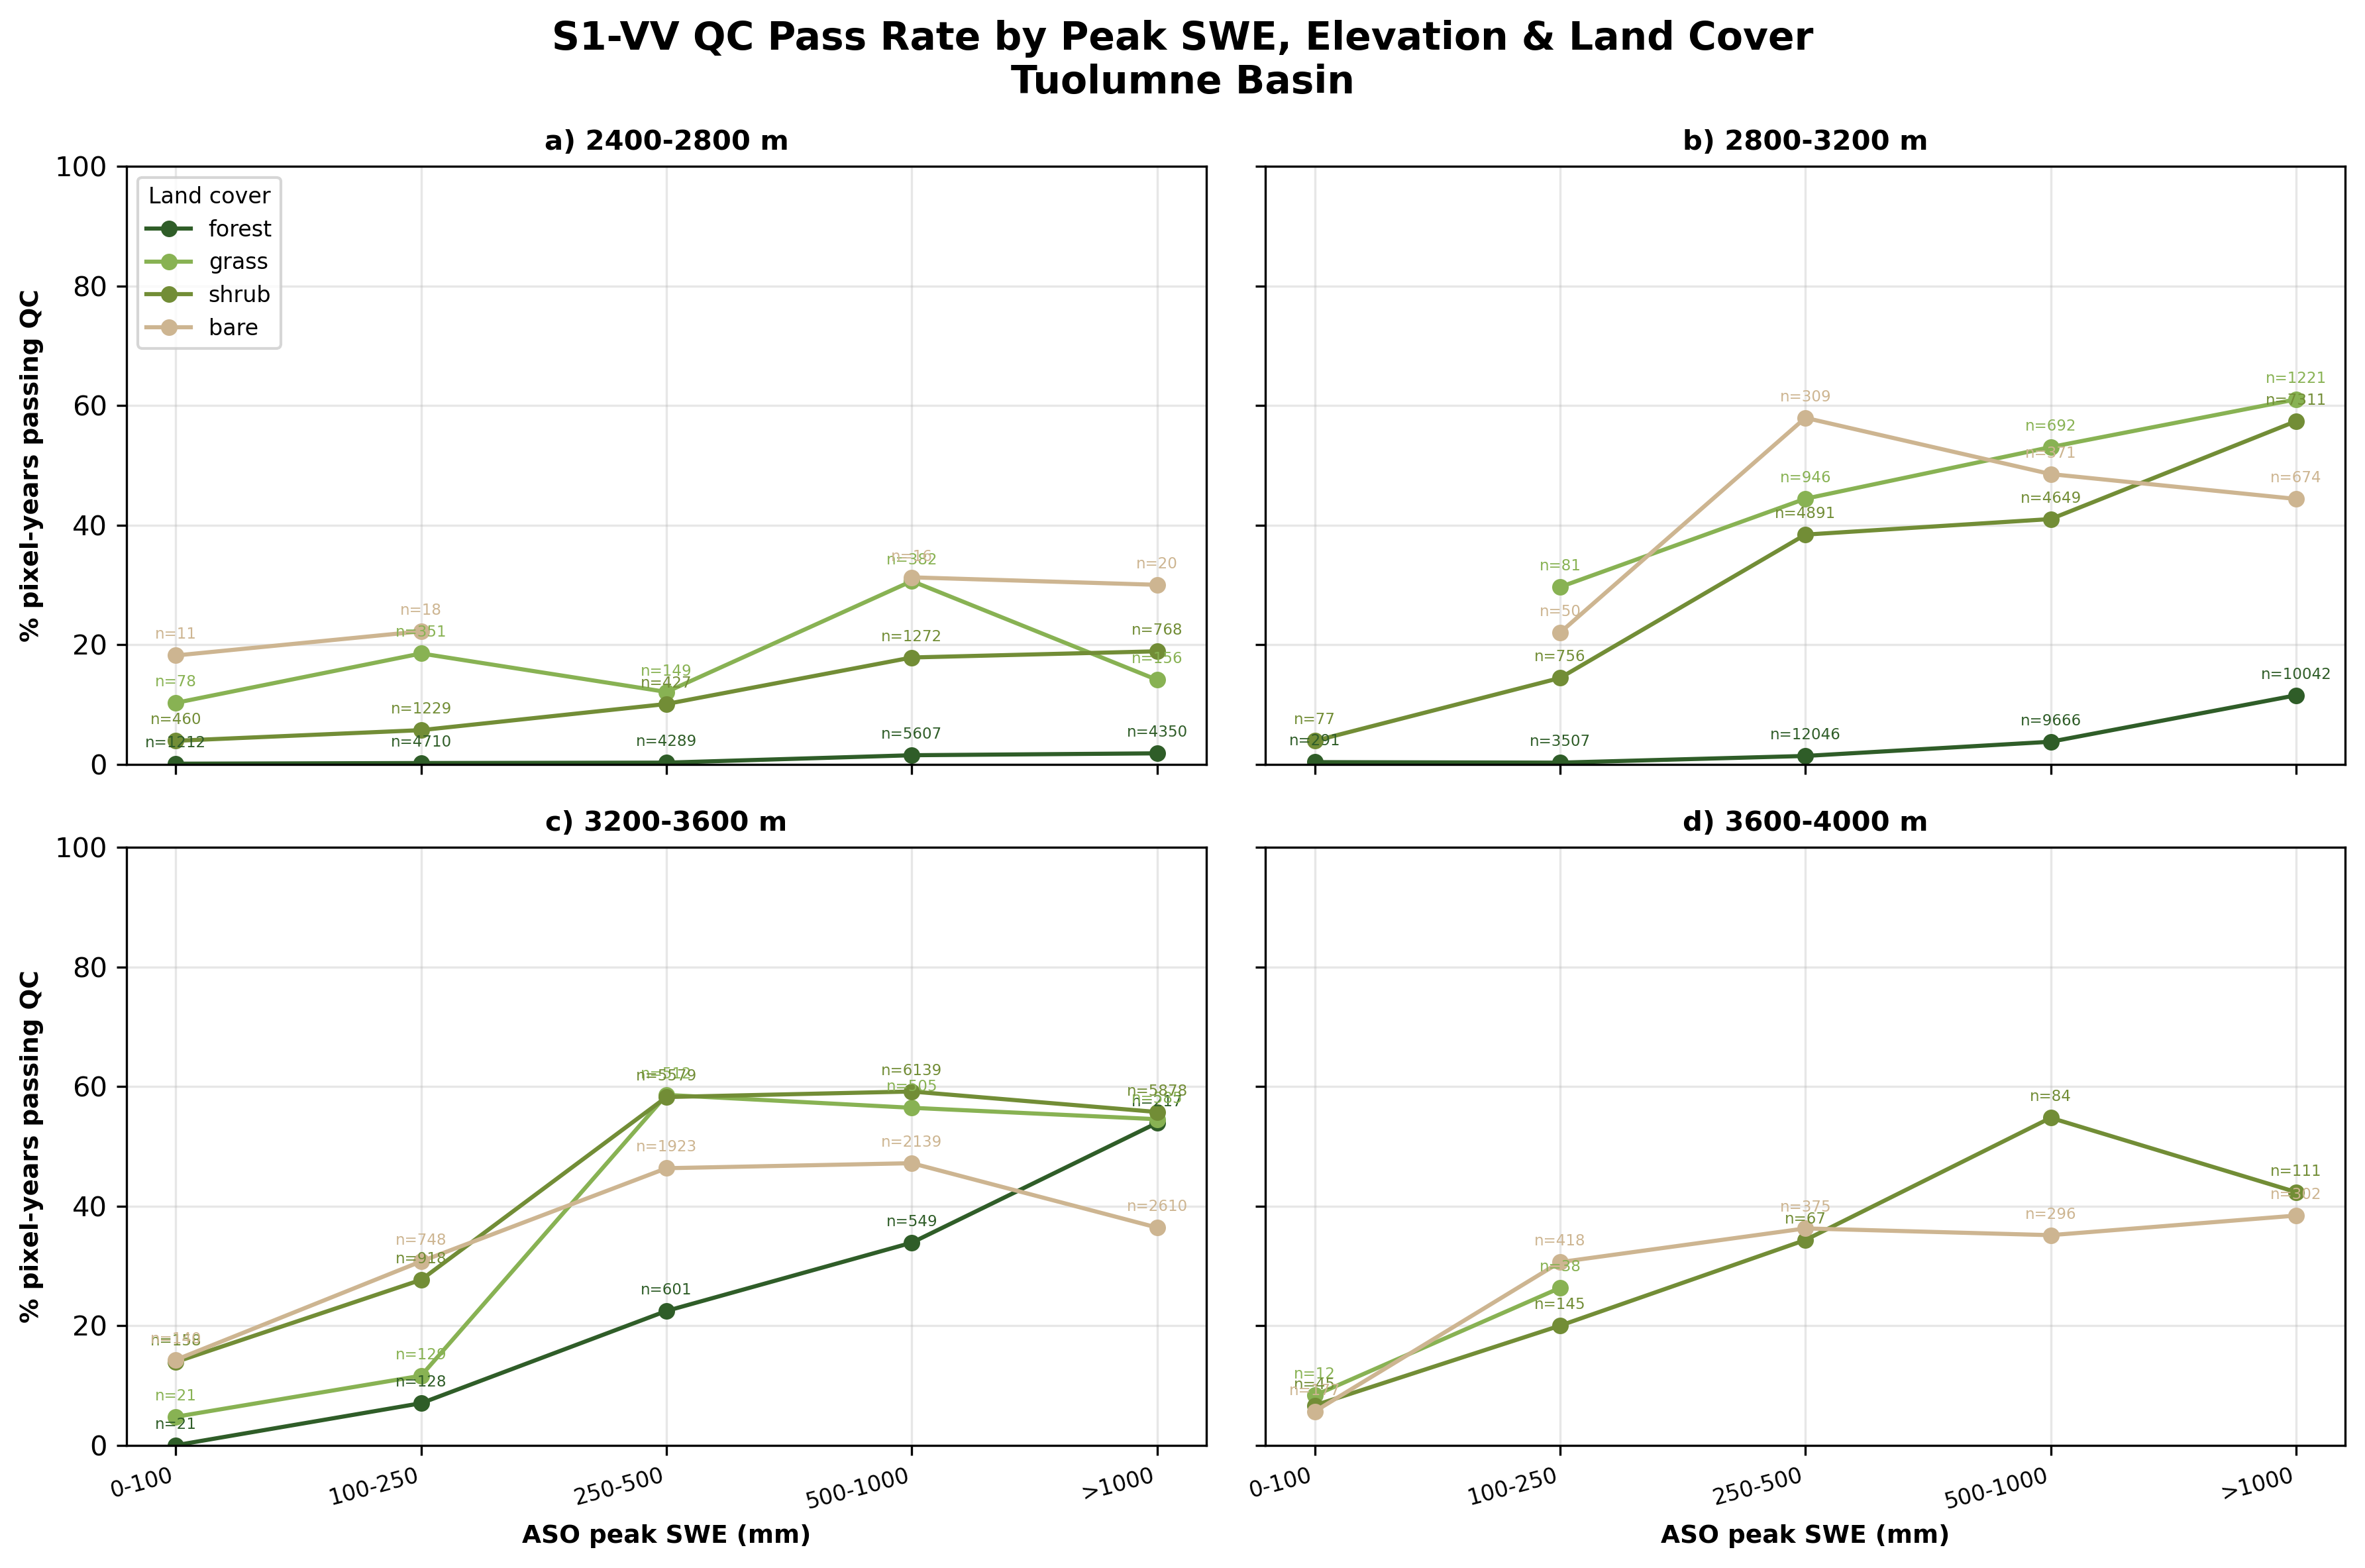

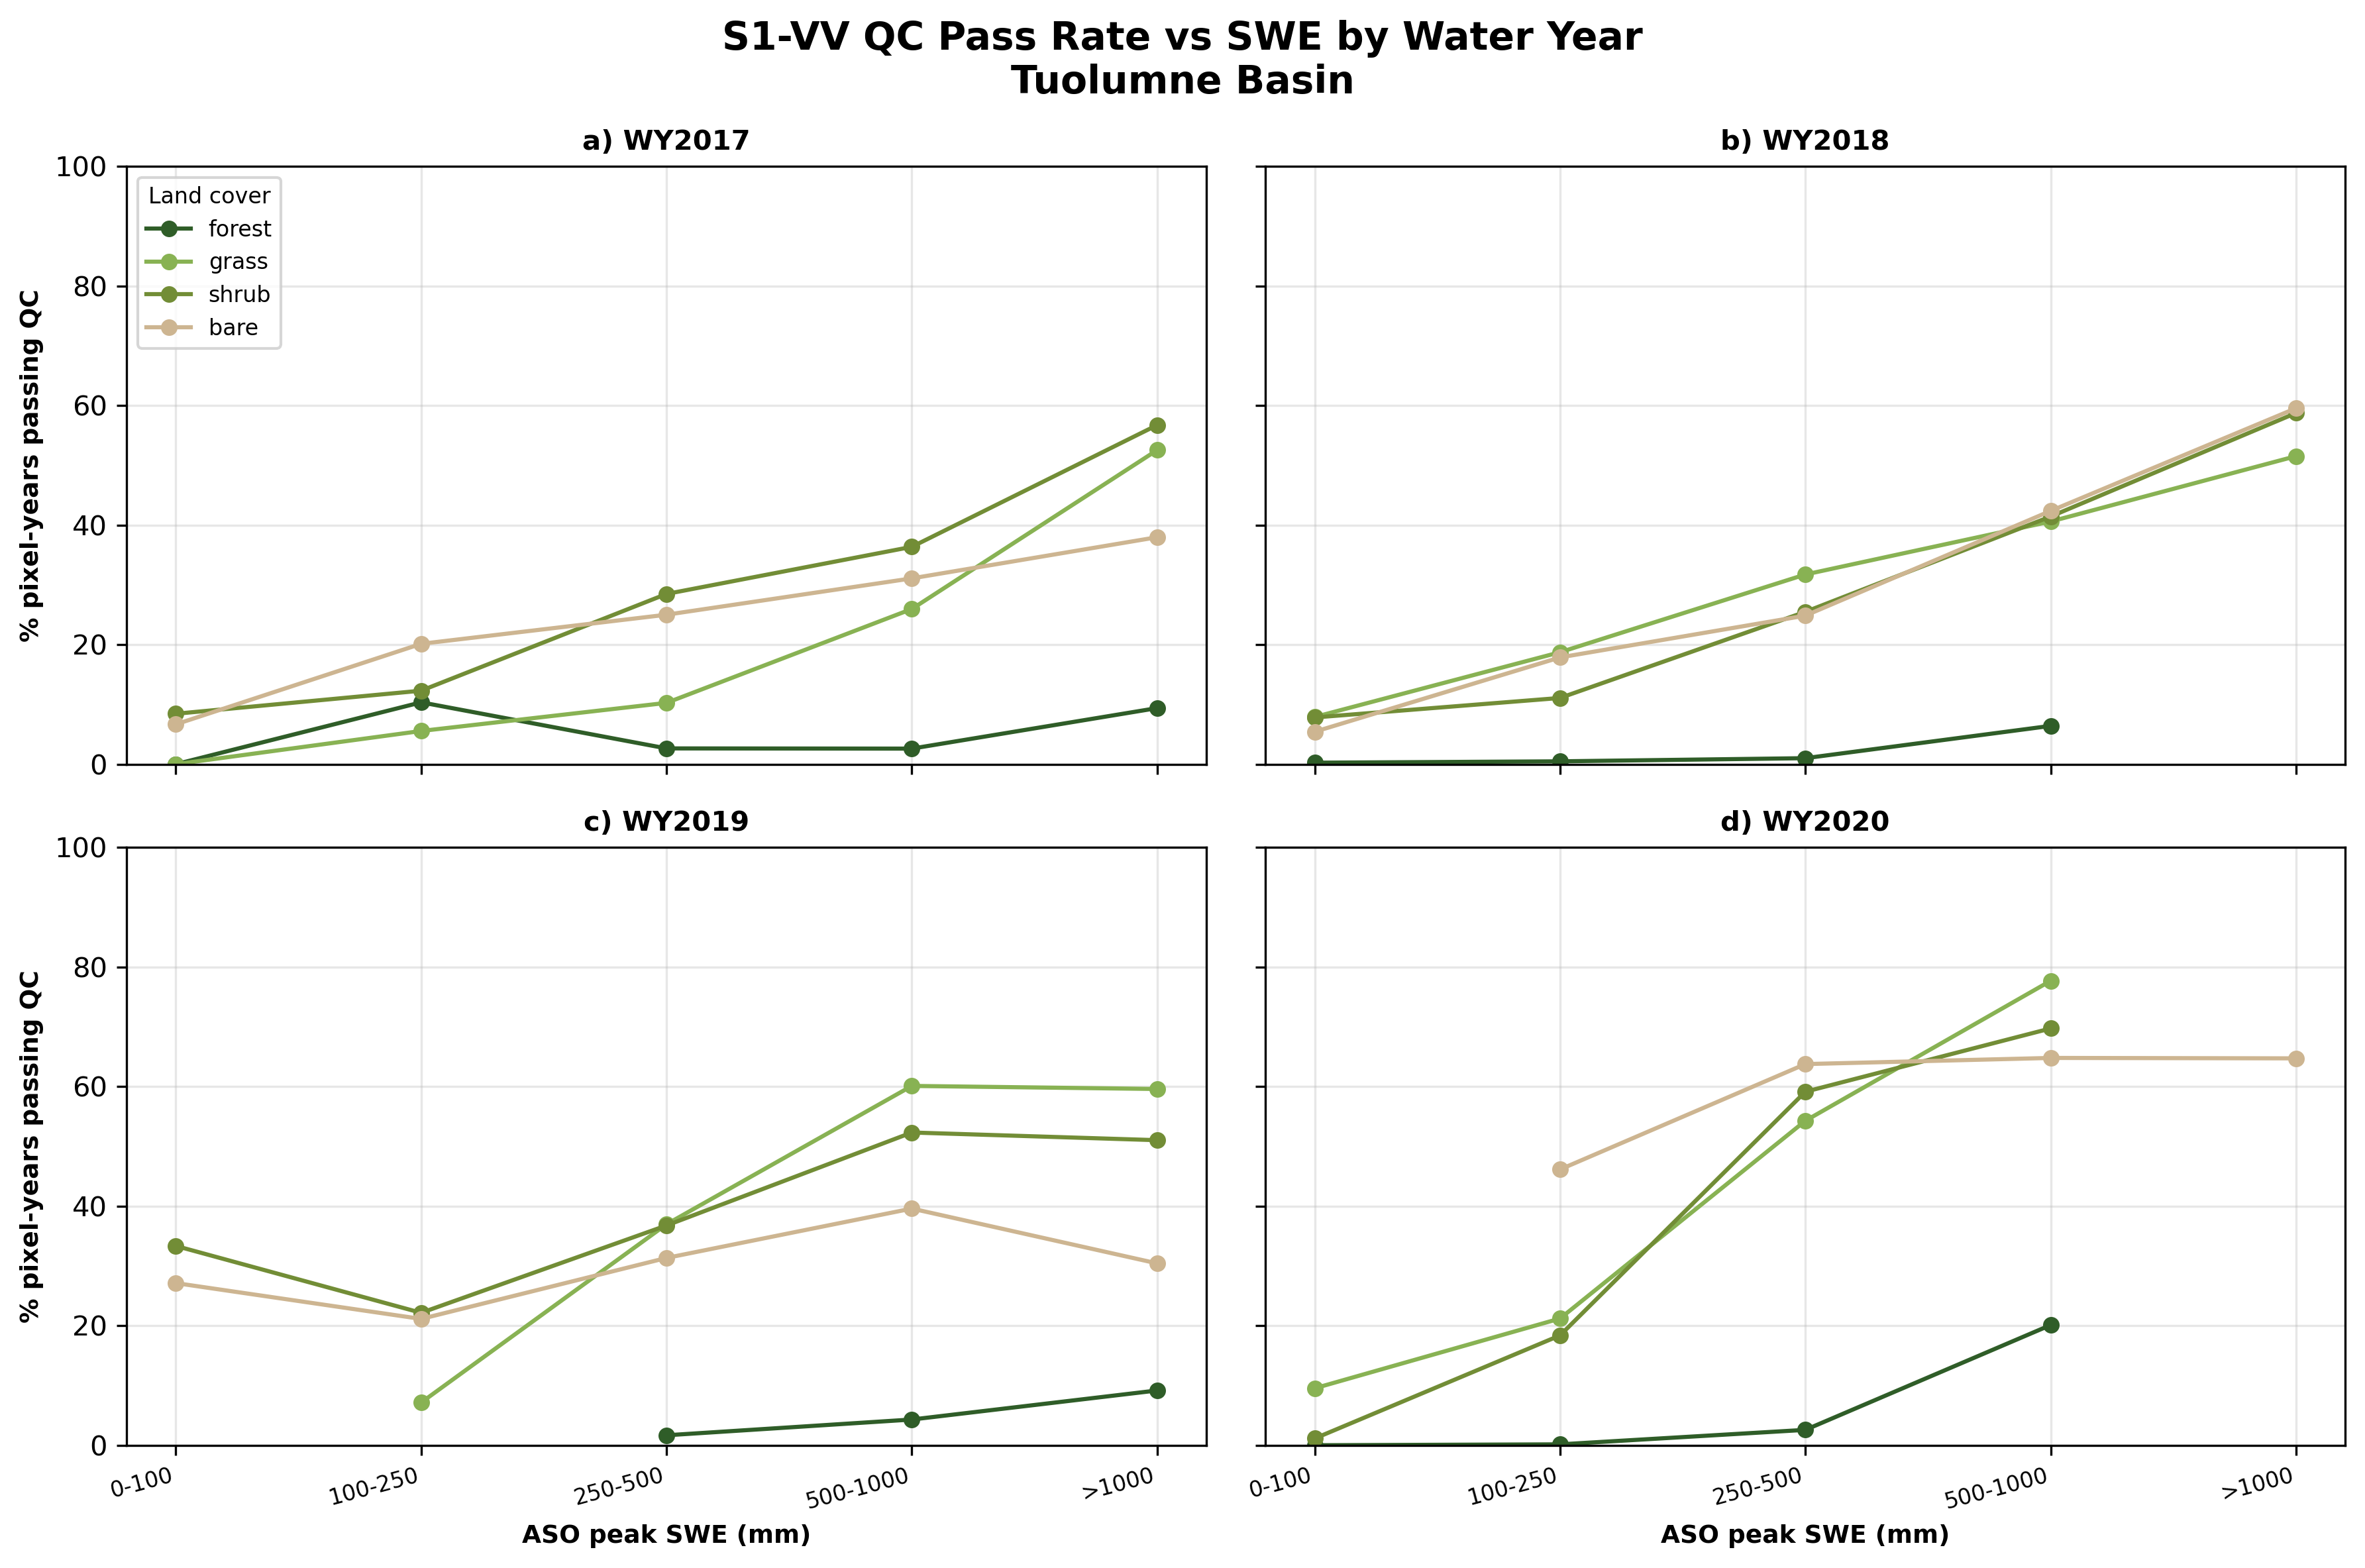

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
from rasterio.enums import Resampling
from matplotlib.lines import Line2D

# Reference grid: terrain 100 m (EPSG:32611)
elev_bin_da = terrain_binned["elev_bin"].rio.write_crs(f"EPSG:{aso_crs}")

# ── Basin mask on terrain grid ─────────────────────────────────────────────────
hgt_uscatm  = terrain_binned["hgt"].rio.write_crs(f"EPSG:{aso_crs}").rio.clip(
    uscatm_proj_gdf.geometry, drop=False)
uscatm_mask = np.isfinite(hgt_uscatm.values)

# ── ASO DEM: reproject to terrain grid (bilinear), feet → meters ───────────────
aso_dem_repr = (
    aso_dem_da.rio.write_crs(f"EPSG:{aso_crs}") * 0.3048
).rio.reproject_match(elev_bin_da, resampling=Resampling.bilinear).values

# ── Elevation bins from reprojected ASO DEM ─────────────────────────────────────
# np.digitize: 1=2400-2800 m, 2=2800-3200 m, 3=3200-3600 m, 4=3600-4000 m
ASO_ELEV_EDGES = np.array([2400, 2800, 3200, 3600, 4000])
aso_elev_bin   = np.digitize(aso_dem_repr, ASO_ELEV_EDGES)

# ── Land cover (already on terrain grid) ───────────────────────────────────────
lc_vals = terrain_binned["landcover"].values

# ── Per-year matching: QC pass/fail x that year's ASO peak SWE ─────────────────
# ASO SWE standard units are meters (m); SWE_SCALE=1000 converts to mm.
# Adjust to 1 if aso_swe is already in mm (check quality-check print below).
SWE_SCALE = 1000

# aso_slice date order (confirmed from aso_slice.date):
#   index 0 = 2017-05-02, 1 = 2018-04-23, 2 = 2019-04-17, 3 = 2020-04-13
YEARS_DATA = [
    (2017, tu_vv_2017, 0),
    (2018, tu_vv_2018, 1),
    (2019, tu_vv_2019, 2),
    (2020, tu_vv_2020, 3),
]

records = []
for wy, vv_ds, aso_idx in YEARS_DATA:

    # QC for this year → terrain grid (nearest: preserves binary 0/1 integrity)
    qc_yr = (
        xr.DataArray(vv_ds["qc_ok"].values.astype(float), dims=["y", "x"],
                     coords={"y": vv_ds.y.values, "x": vv_ds.x.values})
        .rio.write_crs(f"EPSG:{aso_crs}")
        .rio.clip(uscatm_proj_gdf.geometry, drop=False)
        .rio.reproject_match(elev_bin_da, resampling=Resampling.nearest)
        .values
    )

    # ASO SWE for this year → terrain grid (bilinear for continuous field), m→mm
    swe_yr = (
        aso_slice.aso_swe.isel(date=aso_idx)
        .rio.write_crs(f"EPSG:{aso_crs}")
        .rio.reproject_match(elev_bin_da, resampling=Resampling.bilinear)
        .values
    ) * SWE_SCALE

    # Valid pixels: within USCATM, finite SWE >= 0, valid elevation + landcover, no NaN QC
    yr_mask = (uscatm_mask
               & np.isfinite(swe_yr) & (swe_yr >= 0)
               & np.isfinite(aso_dem_repr)
               & ~np.isnan(qc_yr)
               & (aso_elev_bin >= 1) & (aso_elev_bin <= 4)
               & np.isin(lc_vals, [1, 2, 3, 4]))

    idx = np.where(yr_mask)
    records.append(pd.DataFrame({
        "water_year":      wy,
        "qc_pass":         qc_yr[idx].round().astype(int),
        "aso_peak_swe_mm": swe_yr[idx],
        "elevation_m":     aso_dem_repr[idx],
        "elevation_bin":   aso_elev_bin[idx],
        "landcover_code":  lc_vals[idx],
    }))

df = pd.concat(records, ignore_index=True)

# ── Readable labels ─────────────────────────────────────────────────────────────
ELEV_BIN_LABELS = {1: "2400-2800", 2: "2800-3200", 3: "3200-3600", 4: "3600-4000"}
LC_LABEL_MAP    = {1: "forest", 2: "shrub", 3: "grass", 4: "bare"}
df["elev_label"]  = df["elevation_bin"].map(ELEV_BIN_LABELS)
df["lc_class"]    = df["landcover_code"].map(LC_LABEL_MAP)

# SWE bins (mm) — using digitize to avoid Categorical indexing issues
# SWE_BIN_THRESHOLDS = np.array([50, 100, 200, 400])
# SWE_BIN_LABELS     = ["0-50", "50-100", "100-200", "200-400", ">400"]
SWE_BIN_THRESHOLDS = np.array([100, 250, 500, 1000])
SWE_BIN_LABELS     = ["0-100", "100-250", "250-500", "500-1000", ">1000"]
df["swe_bin_idx"]  = np.digitize(df["aso_peak_swe_mm"].values, SWE_BIN_THRESHOLDS)
df["swe_bin"]      = [SWE_BIN_LABELS[i] for i in df["swe_bin_idx"]]

# ═══════════════════════════════════════════════════════════════════════════════
# QUALITY CHECKS
# ═══════════════════════════════════════════════════════════════════════════════
print(f"Total pixel-year records: {len(df):,}")
print(f"ASO SWE raw value range (pre-scale): {df['aso_peak_swe_mm'].min()/SWE_SCALE:.4f} – {df['aso_peak_swe_mm'].max()/SWE_SCALE:.4f}")
print(f"After x{SWE_SCALE}: {df['aso_peak_swe_mm'].min():.0f} – {df['aso_peak_swe_mm'].max():.0f} mm")

print("\n─── Records per water year ───")
for yr, grp in df.groupby("water_year"):
    print(f"  {yr}: {len(grp):,} px-yr  | QC pass rate: {grp['qc_pass'].mean()*100:.1f}%")

print("\n─── Records per elevation bin ───")
for b, bl in ELEV_BIN_LABELS.items():
    n = (df["elevation_bin"] == b).sum()
    print(f"  {bl} m: {n:,}")

print("\n─── SWE distribution per elevation bin (mm) ───")
for b, bl in ELEV_BIN_LABELS.items():
    vals = df.loc[df["elevation_bin"] == b, "aso_peak_swe_mm"]
    if len(vals) > 0:
        print(f"  {bl}: median={vals.median():.0f}  P10={vals.quantile(0.1):.0f}  P90={vals.quantile(0.9):.0f}")

print("\n─── Empty / sparse bins (n < 10) ───")
any_sparse = False
for b, bl in ELEV_BIN_LABELS.items():
    for sl in SWE_BIN_LABELS:
        for lc_name in ["forest", "grass", "shrub", "bare"]:
            n = len(df[(df["elevation_bin"] == b) & (df["swe_bin"] == sl) & (df["lc_class"] == lc_name)])
            if n < 10:
                print(f"  elev={bl} swe={sl} lc={lc_name}: n={n}")
                any_sparse = True
if not any_sparse:
    print("  None — all bins have n >= 10")

# ═══════════════════════════════════════════════════════════════════════════════
# BINNING + AGGREGATION
# ═══════════════════════════════════════════════════════════════════════════════
LC_CATS = [("forest", "#2F5D28"), ("grass", "#88B253"), ("shrub", "#728D36"), ("bare", "#CDB591")]
MIN_N   = 10  # min pixel-years to display a point

def lookup_agg(panel, lc_name):
    sub = panel[panel["lc_class"] == lc_name]
    d   = sub.set_index("swe_bin")[["pct_pass", "n"]].to_dict("index")
    y   = np.array([d.get(sl, {"pct_pass": np.nan})["pct_pass"] for sl in SWE_BIN_LABELS])
    ns  = np.array([d.get(sl, {"n": 0})["n"]                    for sl in SWE_BIN_LABELS])
    return y, ns

# Pooled across all years
agg_pooled = (
    df.groupby(["elevation_bin", "elev_label", "swe_bin", "lc_class"])
    .agg(n=("qc_pass", "count"), pass_sum=("qc_pass", "sum"))
    .reset_index()
)
agg_pooled["pct_pass"] = 100 * agg_pooled["pass_sum"] / agg_pooled["n"]

# Per-year (diagnostic)
agg_by_year = (
    df.groupby(["water_year", "swe_bin", "lc_class"])
    .agg(n=("qc_pass", "count"), pass_sum=("qc_pass", "sum"))
    .reset_index()
)
agg_by_year["pct_pass"] = 100 * agg_by_year["pass_sum"] / agg_by_year["n"]

# ═══════════════════════════════════════════════════════════════════════════════
# PLOTTING — Main: 2x2 elevation panels, lines by landcover
# ═══════════════════════════════════════════════════════════════════════════════
x_pos = np.arange(len(SWE_BIN_LABELS))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=300, sharex=True, sharey=True)
axes_flat = axes.ravel()
labels = ['a','b','c','d']
for ie, (e_bin, el) in enumerate(ELEV_BIN_LABELS.items()):
    ax    = axes_flat[ie]
    panel = agg_pooled[agg_pooled["elevation_bin"] == e_bin]

    for lc_name, lc_color in LC_CATS:
        y, ns = lookup_agg(panel, lc_name)
        y[ns < MIN_N] = np.nan
        ax.plot(x_pos, y, color=lc_color, marker="o", markersize=5,
                linewidth=1.5, label=lc_name)
        for xi, (yi, ni) in enumerate(zip(y, ns)):
            if np.isfinite(yi) and ni >= MIN_N:
                ax.annotate(f"n={ni}", xy=(xi, yi), xytext=(0, 6),
                            textcoords="offset points", fontsize=5.5,
                            ha="center", color=lc_color)

    ax.set_title(f"{labels[ie]}) {el} m", fontweight="bold", fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SWE_BIN_LABELS, rotation=15, ha="right", fontsize=8)
    ax.grid(True, alpha=0.3)
    if ie % 2 == 0:
        ax.set_ylabel("% pixel-years passing QC", fontweight="bold", fontsize=9)
    if ie >= 2:
        ax.set_xlabel("ASO peak SWE (mm)", fontweight="bold", fontsize=9)

lc_handles = [Line2D([0],[0], color=c, marker="o", markersize=5, linewidth=1.5, label=n)
              for n, c in LC_CATS]
axes_flat[0].legend(handles=lc_handles, fontsize=8, frameon=True, loc="upper left",
                    title="Land cover", title_fontsize=8)
fig.suptitle("S1-VV QC Pass Rate by Peak SWE, Elevation & Land Cover\n"
             "Tuolumne Basin",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("./pngs/S8_S1_VV_QC_pass_v_ASO_terrain.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC — year-faceted: QC pass rate vs SWE by water year
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8), dpi=300, sharex=True, sharey=True)
axes2_flat = axes2.ravel()

labels = ['a','b','c','d']
for iy, yr in enumerate([2017, 2018, 2019, 2020]):
    ax    = axes2_flat[iy]
    panel = agg_by_year[agg_by_year["water_year"] == yr]

    for lc_name, lc_color in LC_CATS:
        y, ns = lookup_agg(panel, lc_name)
        y[ns < MIN_N] = np.nan
        ax.plot(x_pos, y, color=lc_color, marker="o", markersize=5,
                linewidth=1.5, label=lc_name)

    ax.set_title(f"{labels[iy]}) WY{yr}", fontweight="bold", fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SWE_BIN_LABELS, rotation=15, ha="right", fontsize=8)
    ax.grid(True, alpha=0.3)
    if iy % 2 == 0:
        ax.set_ylabel("% pixel-years passing QC", fontweight="bold", fontsize=9)
    if iy >= 2:
        ax.set_xlabel("ASO peak SWE (mm)", fontweight="bold", fontsize=9)

axes2_flat[0].legend(handles=lc_handles, fontsize=8, frameon=True, loc="upper left",
                     title="Land cover", title_fontsize=8)
fig2.suptitle("S1-VV QC Pass Rate vs SWE by Water Year\n"
              "Tuolumne Basin",
              fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("./pngs/S9_S1_VV_QC_pass_v_ASO_terrain.png", dpi=300, bbox_inches="tight")
plt.show()
